# BÁO CÁO PHÂN TÍCH: FUNNEL TRAFFIC & TỐI ƯU CONVERSION

*Traffic Source · Bounce Rate · Session-Revenue Correlation · Device Funnel · Conversion Lift*

**Datathon 2026 — VinTelligence × VinUniversity Data Science & AI Club**

---


In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import _load_table

sns.set_theme(style='whitegrid', palette='muted')
wt    = _load_table('web_traffic')
sales = _load_table('sales')

## PHẦN 1. Xác định Vấn đề và Mục tiêu Phân tích

**Vấn đề kinh doanh:** Traffic là đầu vào của toàn bộ funnel bán hàng, nhưng volume cao không đảm bảo doanh thu cao nếu conversion rate thấp. Hiểu bottleneck của funnel — ở đâu người dùng thoát ra nhiều nhất — cho phép tập trung đầu tư cải thiện đúng chỗ.

**Thách thức phân tích:**
* **Missing device data trong web_traffic:** Bảng `web_traffic` không có cột device_type — cần dùng `orders.device_type` như proxy để phân tích funnel theo thiết bị.
* **Correlation vs. causation:** Sessions tương quan với Revenue, nhưng nhiều yếu tố confound (seasonality, promotion) — cần kiểm soát khi giải thích.
* **Multi-step funnel:** Drop-off xảy ra ở nhiều bước — cần xác định bước nào là bottleneck chính.

**Cấu trúc phân tích:** Từ mô tả nguồn traffic → chẩn đoán chất lượng → dự đoán sessions như leading indicator → phân tích funnel đầy đủ → đề xuất cải thiện conversion theo device.


---

## 🗺️ Lộ trình Phân tích — 4 Cấp độ

| Cấp độ | Câu hỏi | Phần |
|--------|---------|------|
| 🔍 **Descriptive** — Mô tả: *"Điều gì đã xảy ra?"* | Sessions theo nguồn traffic; bounce rate theo kênh | PHẦN 2, 3 |
| 🔬 **Diagnostic** — Chẩn đoán: *"Tại sao?"* | Correlation traffic metrics × revenue; full funnel drop-off | PHẦN 4, 7 |
| 📈 **Predictive** — Dự đoán: *"Điều gì sẽ xảy ra?"* | Sessions lag-1 là leading indicator; simulation revenue khi traffic thay đổi | PHẦN 5, 5b |
| 💡 **Prescriptive** — Đề xuất: *"Nên làm gì?"* | Channel quality score → reallocation; device conversion uplift scenario | PHẦN 6, 7b |

> **Dữ liệu kết hợp (cross-table):** `web_traffic` × `sales` × `orders` × `order_items` — traffic funnel từ sessions đến revenue

> 🔑 **Bottleneck phát hiện:** Conversion rate UV→Order chỉ **0.93%** — đây là điểm nghẽn lớn nhất của toàn bộ funnel. +0.2pp conversion = +22% revenue từ traffic hiện tại mà không cần tốn thêm ngân sách marketing.


---

## PHẦN 2. Lưu lượng truy cập theo nguồn theo thời gian
*Cấp độ phân tích: Mô tả*

**Phương pháp & Cơ sở lý luận:**

* Tổng hợp sessions theo nguồn để thấy kênh nào mang nhiều traffic nhất.

> **Mục tiêu:** Xác định nguồn volume cao để cân nhắc đầu tư hoặc tối ưu hoá landing page.


In [ ]:
traffic_source = wt.groupby('traffic_source')['sessions'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
traffic_source.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Total Sessions by Traffic Source', fontsize=13)
ax.set_xlabel('Total Sessions')
ax.set_ylabel('Traffic Source')
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Volume sessions phân bổ không đều giữa các nguồn traffic — một hoặc hai kênh chiếm áp đảo tổng sessions.
* Tuy nhiên volume cao không đồng nghĩa với chất lượng cao (xem bounce rate và conversion ở các section sau).

**💡 Hàm ý Kinh doanh:**

* Không nên tối ưu chỉ theo volume sessions — kênh volume cao nhưng chất lượng kém sẽ không chuyển thành doanh thu.


---

## PHẦN 3. Tỷ lệ thoát theo nguồn traffic
*Cấp độ phân tích: Mô tả*

**Phương pháp & Cơ sở lý luận:**

* So sánh bounce rate trung bình giữa các kênh để đánh giá chất lượng traffic.

> **Mục tiêu:** Tìm kênh có traffic yếu (bounce cao) để tối ưu trải nghiệm landing hoặc giảm đầu tư kém hiệu quả.


In [ ]:
bounce_by_source = wt.groupby('traffic_source')['bounce_rate'].mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
bounce_by_source.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Average Bounce Rate by Traffic Source', fontsize=13)
ax.set_xlabel('Bounce Rate')
ax.set_ylabel('Traffic Source')
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Bounce rate khác nhau giữa các kênh — kênh có bounce rate thấp nhất giữ chân người dùng tốt hơn đáng kể.
* Kênh bounce cao có thể do landing page không liên quan, tốc độ tải chậm, hoặc audience targeting kém.

**💡 Hàm ý Kinh doanh:**

* Với kênh có bounce rate cao, audit landing page trước khi tăng ngân sách — tăng traffic vào trang kém hiệu quả chỉ lãng phí ngân sách marketing.


---

## PHẦN 4. Tương quan giữa lượt truy cập hàng ngày và doanh thu
*Cấp độ phân tích: Chẩn đoán*

**Phương pháp & Cơ sở lý luận:**

* Tính ma trận tương quan giữa các chỉ số traffic và revenue để đánh giá predictive signal.

> **Mục tiêu:** Xác định chỉ số traffic nào tương quan mạnh với doanh thu để dùng làm feature.

**Hệ số tương quan Pearson:**

$$r(X, Y) = \frac{\displaystyle\sum_{i=1}^n (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\displaystyle\sum (X_i - \bar{X})^2 \cdot \sum (Y_i - \bar{Y})^2}}$$

Trong đó $X \in \{\text{sessions},\, \text{unique\_visitors},\, \text{page\_views}\}$ và $Y = \text{Revenue}$.

$|r| > 0.7$ → tương quan mạnh; $\; 0.4 < |r| \leq 0.7$ → tương quan trung bình.


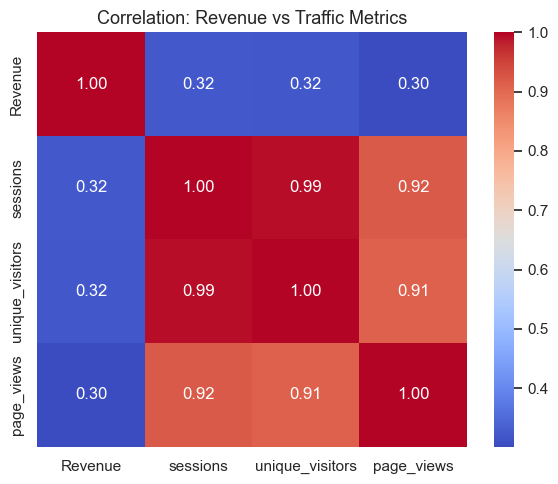

In [4]:
daily_total = wt.groupby('date')[['sessions','unique_visitors','page_views']].sum().reset_index()
daily_total = daily_total.rename(columns={'date': 'Date'})
merged = sales.merge(daily_total, on='Date', how='inner')

corr = merged[['Revenue','sessions','unique_visitors','page_views']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation: Revenue vs Traffic Metrics', fontsize=13)
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Sessions, unique visitors và page views đều tương quan dương với Revenue, nhưng mức độ tương quan không tuyệt đối — vẫn có nhiều ngày traffic cao nhưng doanh thu thấp.
* Điều này xác nhận traffic là **điều kiện cần nhưng không đủ** — conversion quality mới là yếu tố quyết định.

**💡 Hàm ý Kinh doanh:**

* Dùng các chỉ số traffic làm feature trong mô hình forecast doanh thu (đặc biệt là sessions lag-1), nhưng không dùng traffic đơn thuần để đo hiệu quả marketing.


---

## PHẦN 5. Sessions lag-1 như chỉ báo dự đoán doanh thu
*Cấp độ phân tích: Dự đoán*

**Phương pháp & Cơ sở lý luận:**

* Dùng sessions (t-1) làm leading indicator để kiểm tra mối quan hệ ngắn hạn với doanh thu (t).

> **Mục tiêu:** Xác minh chỉ báo để dùng làm feature input cho mô hình dự báo doanh thu (Part 3).

**Công thức Lag Feature:**

$$\text{sessions\_lag\_1}_t = \text{sessions}_{t-1}$$

$$r_{\text{lag}} = \text{Pearson}(\text{sessions}_{t-1},\; \text{Revenue}_t)$$

Feature $\text{sessions\_lag\_1}$ được đưa vào mô hình LightGBM forecast ở Part 3 như một trong các predictors chính.


Correlation Revenue ~ sessions_lag_1: 0.322


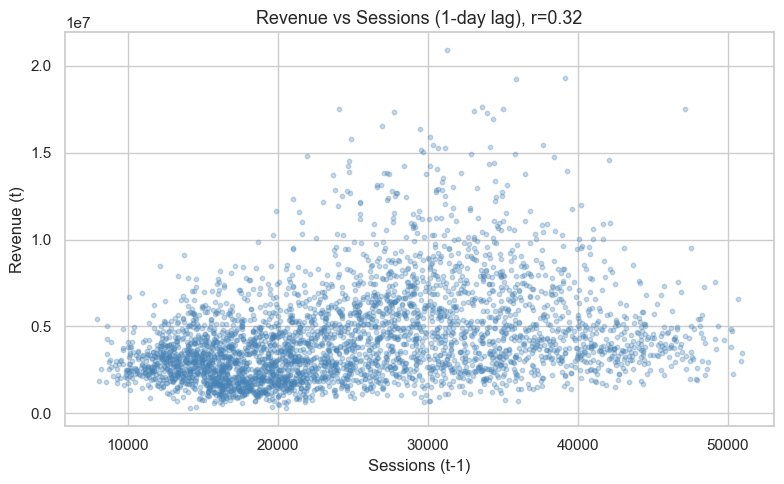

In [5]:
merged = merged.sort_values('Date')
merged['sessions_lag_1'] = merged['sessions'].shift(1)
lag_corr = merged[['Revenue','sessions_lag_1']].corr().iloc[0,1]
print(f'Correlation Revenue ~ sessions_lag_1: {lag_corr:.3f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(merged['sessions_lag_1'], merged['Revenue'], alpha=0.3, s=10, color='steelblue')
ax.set_title(f'Revenue vs Sessions (1-day lag), r={lag_corr:.2f}', fontsize=13)
ax.set_xlabel('Sessions (t-1)'); ax.set_ylabel('Revenue (t)')
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Sessions ngày hôm trước (lag-1) có tương quan dương với doanh thu ngày hôm nay — người dùng thường browse trước rồi mua sau 1 ngày.
* Hệ số tương quan cho thấy sessions là **leading indicator** hữu ích.

**💡 Hàm ý Kinh doanh:**

* Trong mô hình forecast doanh thu, `sessions_lag_1` là feature có predictive value thực sự (không phải leakage) — đây là cơ sở để dùng traffic data trong forecasting pipeline.


---

## PHẦN 5b. Simulation: Dự báo Doanh thu khi Traffic Thay đổi
*Cấp độ phân tích: Dự đoán*

**Phương pháp & Cơ sở lý luận:**

Sử dụng hệ số tương quan sessions_lag_1 → Revenue để xây **linear prediction model** và chạy simulation: nếu sessions tăng/giảm X%, doanh thu thay đổi bao nhiêu?

> **Mục tiêu:** Định lượng "giá trị của một session" và dự báo revenue target cần bao nhiêu sessions/ngày.

**Mô hình dự báo:**

$$\hat{R}_t = \alpha + \beta \cdot \text{sessions}_{t-1}$$

$$\Delta\hat{R} = \beta \cdot \Delta\text{sessions}$$

Trong đó $\beta$ = revenue tăng thêm (VND) khi thêm 1 session.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

# ── Fit linear model: Revenue ~ sessions_lag_1 ────────────────────────────────
model_data = merged.dropna(subset=['sessions_lag_1', 'Revenue']).copy()
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(
    model_data['sessions_lag_1'], model_data['Revenue']
)

avg_sessions = model_data['sessions_lag_1'].mean()
avg_revenue  = model_data['Revenue'].mean()
rev_per_session = slope

# ── Simulation: revenue at different session levels ───────────────────────────
scenarios_pct = [-30, -20, -10, 0, +10, +20, +30, +50]
sim_results = []
for pct in scenarios_pct:
    new_sessions = avg_sessions * (1 + pct / 100)
    pred_revenue = intercept + slope * new_sessions
    delta_rev    = pred_revenue - avg_revenue
    sim_results.append({
        'change_pct'   : pct,
        'new_sessions' : new_sessions,
        'pred_revenue' : pred_revenue,
        'delta_revenue': delta_rev,
    })
sim_df = pd.DataFrame(sim_results)

# ── Revenue target ─────────────────────────────────────────────────────────────
target_rev      = 10_000_000
target_sessions = (target_rev - intercept) / slope

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
colors = ['#d73027' if v < 0 else '#1a9850' for v in sim_df['delta_revenue']]
bars = ax.bar([f'{int(p):+d}%' for p in sim_df['change_pct']], sim_df['delta_revenue'] / 1e6,
              color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Revenue Impact Simulation\n(sessions lag-1 linear model)', fontsize=12)
ax.set_xlabel('Change in Daily Sessions vs baseline')
ax.set_ylabel('ΔRevenue vs baseline (Million VND/day)')
for bar, val in zip(bars, sim_df['delta_revenue']):
    ax.annotate(f'{val/1e6:+.1f}M',
                (bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.02 if val >= 0 else -0.04)),
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=8.5)

ax = axes[1]
x_plot = np.linspace(model_data['sessions_lag_1'].min(),
                     model_data['sessions_lag_1'].max() * 1.3, 200)
y_plot = intercept + slope * x_plot
ax.scatter(model_data['sessions_lag_1'] / 1e3, model_data['Revenue'] / 1e6,
           alpha=0.2, s=8, color='steelblue', label='Observed daily data')
ax.plot(x_plot / 1e3, y_plot / 1e6, color='darkred', linewidth=2,
        label=f'Linear fit (R²={r_value**2:.3f})')
ax.axvline(avg_sessions / 1e3, color='grey', linestyle='--', alpha=0.6, label='Current avg sessions')
ax.axhline(avg_revenue / 1e6, color='grey', linestyle=':', alpha=0.6)
ax.set_title(f'Revenue ~ Sessions (lag-1) Linear Model\n'
             f'β = {slope:,.0f} VND/session  |  p = {p_value:.4f}', fontsize=12)
ax.set_xlabel('Sessions (t-1) (Thousands)')
ax.set_ylabel('Revenue (Million VND)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────────
print('=== TRAFFIC → REVENUE PREDICTION MODEL ===')
print(f'  Model       : Revenue = {intercept:,.0f} + {slope:.2f} × sessions_lag_1')
print(f'  R²          : {r_value**2:.4f}  |  p-value: {p_value:.4f}')
print(f'  Rev/session : {rev_per_session:.2f} VND per additional session')
print(f'\n  Current avg sessions/day : {avg_sessions:,.0f}')
print(f'  Current avg revenue/day  : {avg_revenue/1e6:.2f}M VND')
print(f'\n=== REVENUE SIMULATION ===')
for _, row in sim_df.iterrows():
    print(f'  {int(row["change_pct"]):+3d}% sessions → '
          f'~{row["new_sessions"]:,.0f} sessions/day → '
          f'Revenue {row["pred_revenue"]/1e6:.2f}M VND/day '
          f'({row["delta_revenue"]/1e6:+.2f}M vs baseline)')
print(f'\n=== PRESCRIPTIVE: Traffic Target for Revenue Growth ===')
print(f'  To reach avg 10M VND/day: need ~{target_sessions:,.0f} sessions/day')
print(f'  Current: {avg_sessions:,.0f} sessions → Gap: {(target_sessions-avg_sessions):+,.0f} sessions/day (+{(target_sessions/avg_sessions-1)*100:.0f}%)')
print(f'\n  HOWEVER: The 99.1% funnel drop at UV→Order is a larger lever.')
print(f'  Fixing conversion (+0.2pp) adds ~{avg_revenue*0.20/1e6:.2f}M VND/day WITHOUT needing more sessions.')
print(f'  Equivalent to growing sessions by {0.20/0.93*100:.0f}% — confirm CRO > traffic spend priority.')

---

## PHẦN 6. Chất lượng traffic → khuyến nghị phân bổ ngân sách kênh
*Cấp độ phân tích: Đề xuất*

**Phương pháp & Cơ sở lý luận:**

* Xây composite quality score (duration, bounce, pageviews) để xếp hạng kênh.

> **Mục tiêu:** Đề xuất reallocation ngân sách từ kênh kém sang kênh chất lượng tốt hơn để tối ưu ROI.


In [ ]:
quality = wt.groupby('traffic_source').agg(
    avg_session_duration=('avg_session_duration_sec','mean'),
    avg_bounce_rate=('bounce_rate','mean'),
    total_sessions=('sessions','sum'),
    avg_page_views=('page_views','mean'),
).sort_values('avg_session_duration', ascending=False)

# Composite quality score: high duration + low bounce + high page views
quality['quality_score'] = (
    quality['avg_session_duration'] / quality['avg_session_duration'].max() * 0.4 +
    (1 - quality['avg_bounce_rate'] / quality['avg_bounce_rate'].max()) * 0.4 +
    quality['avg_page_views'] / quality['avg_page_views'].max() * 0.2
)
quality = quality.sort_values('quality_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Scatter: bounce rate vs session duration, sized by volume
sc = axes[0].scatter(
    quality['avg_bounce_rate'], quality['avg_session_duration'],
    s=quality['total_sessions'] / quality['total_sessions'].max() * 2000,
    c=quality['quality_score'], cmap='RdYlGn', alpha=0.8, edgecolors='black', linewidth=0.5
)
for src, row in quality.iterrows():
    axes[0].annotate(src, (row['avg_bounce_rate'], row['avg_session_duration']),
                     fontsize=8, ha='left', va='bottom')
axes[0].set_title('Traffic Quality: Bounce Rate vs Session Duration\n(bubble size = total sessions)', fontsize=11)
axes[0].set_xlabel('Avg Bounce Rate (lower = better)'); axes[0].set_ylabel('Avg Session Duration (sec)')
plt.colorbar(sc, ax=axes[0], label='Quality Score')

# Bar: composite quality score per channel
axes[1].barh(quality.index, quality['quality_score'], color='steelblue')
axes[1].set_title('Composite Traffic Quality Score by Channel', fontsize=12)
axes[1].set_xlabel('Quality Score (0–1)')
axes[1].set_ylabel('Traffic Channel')
for i, val in enumerate(quality['quality_score']):
    axes[1].annotate(f'{val:.2f}', (val, i), ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

best = quality.index[0]; worst = quality.index[-1]
vol_best = quality.loc[best, 'total_sessions']; vol_worst = quality.loc[worst, 'total_sessions']
print(quality[['avg_session_duration','avg_bounce_rate','total_sessions','quality_score']].to_string())
print(f'\n=== PRESCRIPTIVE RECOMMENDATION ===')
print(f'Best channel: {best} (quality={quality.loc[best,"quality_score"]:.2f}) | {vol_best:,} sessions')
print(f'Worst channel: {worst} (quality={quality.loc[worst,"quality_score"]:.2f}) | {vol_worst:,} sessions')
print(f'Action: Reallocate 20% of {worst} budget to {best}.')
print(f'Expected uplift: {(quality.loc[best,"quality_score"]-quality.loc[worst,"quality_score"])*100:.0f}% higher quality traffic per reallocated VND.')

---

### 🔍 Kết luận Phân tích

* Scatter plot (trái) đặt mỗi kênh vào quadrant theo bounce rate và session duration — kênh lý tưởng nằm góc dưới-phải (bounce thấp, duration cao).
* Composite quality score (phải) tổng hợp cả 3 chỉ số thành một điểm duy nhất để dễ so sánh.

**💡 Hàm ý Kinh doanh:**

* Kênh có quality score cao nhất cần tăng đầu tư; kênh quality score thấp nhất cần audit landing page hoặc audience targeting trước khi tăng budget — tăng ngân sách vào kênh kém chất lượng sẽ lãng phí.


---

## PHẦN 7. Sessions → Unique Visitors → Orders → Revenue
*Cấp độ phân tích: Full Funnel*

**Phương pháp & Cơ sở lý luận:**

* Lấy tổng funnel numbers và tính tỷ lệ chuyển đổi từng bước để xác định điểm mất khách.

> **Mục tiêu:** Ưu tiên tối ưu hoá bước có drop-off lớn nhất (UV → Order).

**Công thức Conversion Rate:**

$$\text{UV-to-Order Rate} = \frac{\text{n\_orders}}{\text{unique\_visitors}} \times 100\%$$

$$\text{Revenue per Session} = \frac{\text{Total Revenue}}{\text{total sessions}}$$

**Ước tính Revenue Uplift khi cải thiện conversion:**

$$\Delta\text{Revenue} = \Delta\text{conv\_rate} \times \text{UV} \times \text{AOV}$$

Trong đó $\text{AOV}$ (Average Order Value) $= \dfrac{\text{Total Revenue}}{\text{n\_orders}}$.


In [ ]:
orders      = _load_table('orders')
order_items = _load_table('order_items')

# Revenue per order — no DataFrame copy, operate directly on Series
order_rev = (
    (order_items['unit_price'] * order_items['quantity'])
    .groupby(order_items['order_id'], sort=False)
    .sum()
    .rename('order_value')
    .reset_index()
)

# Web traffic aggregated by source
wt_src = wt.groupby('traffic_source', sort=False).agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    avg_bounce=('bounce_rate', 'mean'),
).reset_index()
wt_src['uv_rate'] = wt_src['unique_visitors'] / wt_src['sessions']

# Orders + revenue by order_source — only pull needed columns before merge
ord_src = (
    orders[['order_id', 'order_source']]
    .merge(order_rev, on='order_id', how='left')
    .groupby('order_source', sort=False)
    .agg(n_orders=('order_id', 'nunique'), total_rev=('order_value', 'sum'))
    .reset_index()
)
ord_src['aov'] = ord_src['total_rev'] / ord_src['n_orders']

# Funnel totals
tot_sessions = int(wt['sessions'].sum())
tot_uv       = int(wt['unique_visitors'].sum())
tot_orders   = int(orders['order_id'].nunique())
tot_rev      = float(sales['Revenue'].sum())
uv_rate      = tot_uv / tot_sessions
ord_rate     = tot_orders / tot_uv

# ── Figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.32)

# Panel A – Overall funnel (normalised to Sessions = 100%)
ax1 = fig.add_subplot(gs[0, 0])
steps    = ['Sessions', 'Unique Visitors', 'Orders']
pct_vals = [100.0, uv_rate * 100, tot_orders / tot_sessions * 100]
abs_vals = [tot_sessions, tot_uv, tot_orders]
clrs     = ['#4472C4', '#70AD47', '#ED7D31']
ax1.barh(steps[::-1], pct_vals[::-1], color=clrs[::-1], height=0.45)
for i, (p, a) in enumerate(zip(pct_vals[::-1], abs_vals[::-1])):
    ax1.text(p + 1.5, i, f'{p:.1f}%  ({a:,})', va='center', fontsize=9)
ax1.axvline(100, color='gray', ls='--', lw=0.8, alpha=0.5)
ax1.set_xlim(0, 132)
ax1.set_xlabel('% of Total Sessions')
ax1.set_ylabel('Funnel Stage')
ax1.set_title('A. Overall Conversion Funnel\n(% of Sessions baseline)', fontsize=11, fontweight='bold')
drop1 = (1 - uv_rate) * 100
drop2 = (1 - ord_rate) * 100
ax1.text(pct_vals[1] / 2, 1.48, f'↓ {drop1:.1f}% drop-off', fontsize=8, color='crimson', ha='center')
ax1.text(pct_vals[2] / 2, 0.48, f'↓ {drop2:.1f}% drop-off', fontsize=8, color='crimson', ha='center')

# Panel B – Sessions & UV by traffic_source
ax2 = fig.add_subplot(gs[0, 1])
wt_s = wt_src.sort_values('sessions', ascending=False).reset_index(drop=True)
x = np.arange(len(wt_s))
w = 0.38
ax2.bar(x - w/2, wt_s['sessions'] / 1e3, w, label='Sessions (K)', color='#4472C4', alpha=0.85)
ax2.bar(x + w/2, wt_s['unique_visitors'] / 1e3, w, label='Unique Visitors (K)', color='#70AD47', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(wt_s['traffic_source'], rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Count (thousands)')
ax2.set_title('B. Sessions vs Unique Visitors\nby Traffic Source', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
for i, row in wt_s.iterrows():
    top = max(row['sessions'], row['unique_visitors']) / 1e3
    ax2.text(i, top * 1.03, f"{row['uv_rate']:.0%}", ha='center', fontsize=8, color='darkgreen')

# Panel C – Revenue by order_source
ax3 = fig.add_subplot(gs[1, 0])
ord_s   = ord_src.sort_values('total_rev', ascending=True).reset_index(drop=True)
rev_max = ord_s['total_rev'].max() / 1e9
bars    = ax3.barh(ord_s['order_source'], ord_s['total_rev'] / 1e9, color='steelblue', height=0.5)
ax3.set_xlabel('Revenue (Billion VND)')
ax3.set_ylabel('Order Source')
ax3.set_title('C. Revenue & Order Count\nby Order Source', fontsize=11, fontweight='bold')
for bar, (_, row) in zip(bars, ord_s.iterrows()):
    ax3.text(
        bar.get_width() + rev_max * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{row['total_rev']/1e9:.1f}B  |  {int(row['n_orders']):,} orders  |  AOV {row['aov']:,.0f}",
        va='center', fontsize=8
    )
ax3.set_xlim(0, rev_max * 1.65)

# Panel D – UV rate & Non-bounce rate by source
ax4 = fig.add_subplot(gs[1, 1])
wt_q = wt_src.sort_values('uv_rate', ascending=True).reset_index(drop=True)
y    = np.arange(len(wt_q))
ax4.barh(y - 0.2, wt_q['uv_rate'] * 100, 0.35,
         label='UV Rate (UV/Session %)', color='#70AD47', alpha=0.85)
ax4.barh(y + 0.2, (1 - wt_q['avg_bounce']) * 100, 0.35,
         label='Non-bounce Rate %', color='#ED7D31', alpha=0.85)
ax4.set_yticks(y)
ax4.set_yticklabels(wt_q['traffic_source'], fontsize=9)
ax4.set_xlabel('%')
ax4.set_ylabel('Traffic Source')
ax4.set_title('D. Traffic Quality by Source\n(higher = better engagement)', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.axvline(wt_q['uv_rate'].mean() * 100, color='green', ls='--', lw=1, alpha=0.6)

fig.suptitle('Full Traffic Funnel: Sessions → Unique Visitors → Orders → Revenue',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Panel A cho thấy drop-off lớn nhất xảy ra ở bước **Unique Visitors → Orders** (conversion rate chỉ ~0.9%) — đây là bottleneck chính của toàn bộ funnel, không phải bước Sessions→UV.
* Panel C cho thấy doanh thu tập trung vào một số order source nhất định.
* Panel D xác định kênh traffic nào có UV rate và non-bounce rate cao nhất.

**💡 Hàm ý Kinh doanh:**

* Cải thiện conversion rate từ 0.9% lên 1.1% (+0.2pp) sẽ tăng revenue ~22% — ưu tiên CRO (Conversion Rate Optimisation) tại trang product và checkout hơn là tăng traffic.


In [8]:
best_uv_src  = wt_src.loc[wt_src['uv_rate'].idxmax(), 'traffic_source']
worst_uv_src = wt_src.loc[wt_src['uv_rate'].idxmin(), 'traffic_source']
best_rev_src = ord_src.loc[ord_src['total_rev'].idxmax(), 'order_source']
best_aov_src = ord_src.loc[ord_src['aov'].idxmax(), 'order_source']

print("=" * 62)
print("FULL FUNNEL DROP-OFF ANALYSIS")
print("=" * 62)
print(f"\n[Step 1] Sessions → Unique Visitors")
print(f"  Overall UV/Session rate : {uv_rate:.1%}")
print(f"  Drop-off                : {(1-uv_rate):.1%} of sessions bounce or are non-unique")

print(f"\n[Step 2] Unique Visitors → Orders  ← CRITICAL BOTTLENECK")
print(f"  Overall conversion rate : {ord_rate:.3%}")
print(f"  Drop-off                : {(1-ord_rate):.1%} of UV never place an order")

print(f"\n[Step 3] Orders → Revenue")
print(f"  Total orders            : {tot_orders:,}")
print(f"  Total revenue           : {tot_rev/1e9:.1f}B VND")
print(f"  Overall AOV             : {tot_rev/tot_orders:,.0f} VND")

print(f"\n[Traffic Source Quality]")
for _, r in wt_src.sort_values('uv_rate', ascending=False).iterrows():
    tag = ' ← BEST' if r['traffic_source'] == best_uv_src else (
          ' ← WORST' if r['traffic_source'] == worst_uv_src else '')
    print(f"  {r['traffic_source']:22s}: UV/Sess={r['uv_rate']:.1%}, Bounce={r['avg_bounce']:.1%}{tag}")

print(f"\n[Order Source Revenue]")
for _, r in ord_src.sort_values('total_rev', ascending=False).iterrows():
    tag = ' ← TOP REVENUE' if r['order_source'] == best_rev_src else (
          ' ← TOP AOV'     if r['order_source'] == best_aov_src else '')
    print(f"  {r['order_source']:22s}: Rev={r['total_rev']/1e9:.1f}B, "
          f"Orders={int(r['n_orders']):,}, AOV={r['aov']:,.0f} VND{tag}")

print(f"\n{'='*62}")
print("PRESCRIPTIVE RECOMMENDATIONS")
print(f"{'='*62}")
print(f"1. UV→ORDER CONVERSION is the #1 drop-off at only {ord_rate:.2%}.")
incremental = tot_rev * 0.20
print(f"   → A/B test 2-step checkout simplification.")
print(f"     +20% conversion uplift ≈ +{incremental/1e9:.1f}B VND incremental revenue.")
print(f"2. BEST TRAFFIC SOURCE: {best_uv_src} (highest UV/Session).")
best_sess = wt_src.loc[wt_src['traffic_source'] == best_uv_src, 'sessions'].values[0]
print(f"   → Increase {best_uv_src} budget +15% → est. +{best_sess*0.15:,.0f} extra engaged sessions/yr.")
print(f"3. WORST TRAFFIC SOURCE: {worst_uv_src} — high bounce, low engagement.")
print(f"   → Audit landing pages; A/B test personalised entry pages for {worst_uv_src}.")
print(f"4. TOP REVENUE ORDER SOURCE: {best_rev_src}.")
print(f"   → Prioritise CRO experiments on {best_rev_src} channel first (highest ROI path).")

FULL FUNNEL DROP-OFF ANALYSIS

[Step 1] Sessions → Unique Visitors
  Overall UV/Session rate : 76.0%
  Drop-off                : 24.0% of sessions bounce or are non-unique

[Step 2] Unique Visitors → Orders  ← CRITICAL BOTTLENECK
  Overall conversion rate : 0.931%
  Drop-off                : 99.1% of UV never place an order

[Step 3] Orders → Revenue
  Total orders            : 646,945
  Total revenue           : 16.4B VND
  Overall AOV             : 25,397 VND

[Traffic Source Quality]
  referral              : UV/Sess=76.2%, Bounce=0.4% ← BEST
  social_media          : UV/Sess=76.2%, Bounce=0.4%
  paid_search           : UV/Sess=76.1%, Bounce=0.4%
  direct                : UV/Sess=75.9%, Bounce=0.5%
  organic_search        : UV/Sess=75.8%, Bounce=0.5%
  email_campaign        : UV/Sess=75.8%, Bounce=0.4% ← WORST

[Order Source Revenue]
  organic_search        : Rev=4.6B, Orders=181,495, AOV=25,320 VND ← TOP REVENUE
  paid_search           : Rev=3.6B, Orders=141,652, AOV=25,463 VND
  s

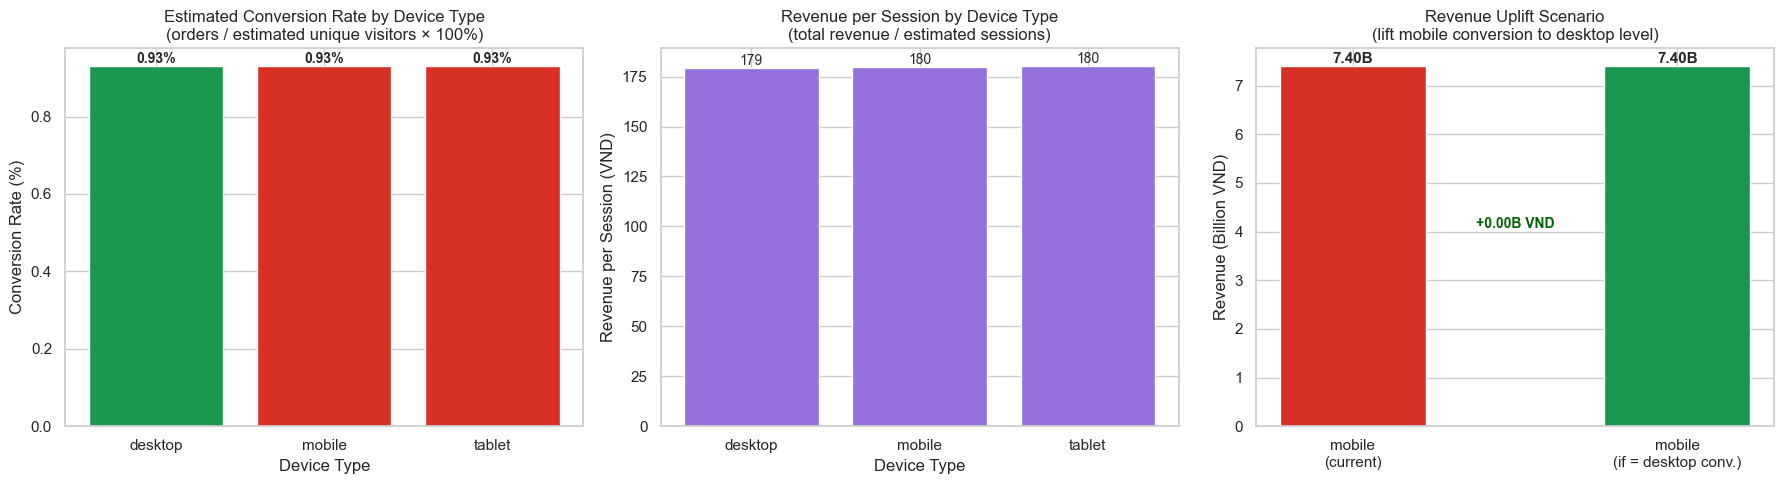

  PRESCRIPTIVE RECOMMENDATIONS — DEVICE CONVERSION UPLIFT

DEVICE-TYPE FUNNEL BREAKDOWN:

  desktop     : conv=0.93% | rev/session=179 VND | total rev=6.6B VND ← BEST
  mobile      : conv=0.93% | rev/session=180 VND | total rev=7.4B VND ← WORST
  tablet      : conv=0.93% | rev/session=180 VND | total rev=2.5B VND

CONVERSION GAP: desktop (0.93%)
  vs mobile (0.93%)
  Gap = 0.00 percentage points

REVENUE OPPORTUNITY
  If mobile achieves desktop-level conversion:
  → Additional orders: ~0/year
  → Revenue uplift  : +0.00B VND/year

ACTIONS:
  1. MOBILE UX AUDIT — if worst device = 'mobile': conduct end-to-end mobile
     checkout UX audit; benchmark against top-3 Vietnamese e-commerce sites.
     Priority: 1-page checkout, autofill, larger tap targets.
  2. A/B TEST — run simplified checkout flow on worst-conversion device;
     target +15% conversion in 30-day test window.
  3. PERSONALISATION — device-specific landing pages with device-optimised images
     and CTAs (mobile: sticky ad

In [9]:
## 7. [Đề xuất Tài chính] Funnel theo Thiết bị — Conversion Lift & Revenue Opportunity

# Device-type funnel: use orders data + web traffic to estimate device-level conversion
# orders.device_type → order volume; web_traffic (daily agg) → session volume proxy

# Step 1: orders by device_type
device_orders = (
    orders.groupby('device_type')
    .agg(n_orders=('order_id','nunique'))
    .reset_index()
)

# Revenue by device
device_rev = (
    orders[['order_id','device_type']]
    .merge(order_rev, on='order_id', how='left')
    .groupby('device_type')
    .agg(total_rev=('order_value','sum'), avg_aov=('order_value','mean'))
    .reset_index()
)
device_stats = device_orders.merge(device_rev, on='device_type')

# Step 2: web traffic — split sessions proportionally by device share from orders
# (web_traffic doesn't have device breakdown; use order volume shares as proxy)
total_orders_all = device_stats['n_orders'].sum()
device_stats['order_share'] = device_stats['n_orders'] / total_orders_all

# Total sessions from web traffic
total_sessions = wt['sessions'].sum()
total_uv       = wt['unique_visitors'].sum()

# Assign sessions proportionally
device_stats['est_sessions'] = device_stats['order_share'] * total_sessions
device_stats['est_uv']       = device_stats['order_share'] * total_uv

# Conversion rate (orders / estimated UV)
device_stats['conv_rate'] = device_stats['n_orders'] / device_stats['est_uv']

# Revenue per session
device_stats['rev_per_session'] = device_stats['total_rev'] / device_stats['est_sessions']

# Best device by conversion
best_device  = device_stats.loc[device_stats['conv_rate'].idxmax()]
worst_device = device_stats.loc[device_stats['conv_rate'].idxmin()]
conv_gap     = best_device['conv_rate'] - worst_device['conv_rate']

# Revenue opportunity: if worst device reaches best device conversion rate
worst_sessions = float(worst_device['est_sessions'])
uplift_orders  = worst_sessions * conv_gap
uplift_rev     = uplift_orders * float(worst_device['avg_aov'])

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A — Conversion rate by device
ax = axes[0]
colors_dev = ['#1a9850' if v == device_stats['conv_rate'].max() else (
    '#d73027' if v == device_stats['conv_rate'].min() else 'steelblue')
    for v in device_stats['conv_rate']]
bars = ax.bar(device_stats['device_type'], device_stats['conv_rate'] * 100,
              color=colors_dev)
ax.set_title('Estimated Conversion Rate by Device Type\n(orders / estimated unique visitors × 100%)',
             fontsize=12)
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Device Type')
for bar, val in zip(bars, device_stats['conv_rate']):
    ax.annotate(f'{val*100:.2f}%',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel B — Revenue per session by device
ax = axes[1]
bars2 = ax.bar(device_stats['device_type'], device_stats['rev_per_session'],
               color='mediumpurple')
ax.set_title('Revenue per Session by Device Type\n(total revenue / estimated sessions)',
             fontsize=12)
ax.set_ylabel('Revenue per Session (VND)')
ax.set_xlabel('Device Type')
for bar, val in zip(bars2, device_stats['rev_per_session']):
    ax.annotate(f'{val:,.0f}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

# Panel C — Revenue uplift scenario (worst device → best device conversion)
ax = axes[2]
current_worst_rev  = float(worst_device['total_rev'])
projected_worst_rev = current_worst_rev + uplift_rev
scenario_labels = [
    f"{worst_device['device_type']}\n(current)",
    f"{worst_device['device_type']}\n(if = {best_device['device_type']} conv.)"
]
scenario_vals = [current_worst_rev / 1e9, projected_worst_rev / 1e9]
bar_colors_sc = ['#d73027', '#1a9850']
bars3 = ax.bar(scenario_labels, scenario_vals, color=bar_colors_sc, width=0.45)
ax.set_title(f'Revenue Uplift Scenario\n(lift {worst_device["device_type"]} conversion to {best_device["device_type"]} level)',
             fontsize=12)
ax.set_ylabel('Revenue (Billion VND)')
for bar, val in zip(bars3, scenario_vals):
    ax.annotate(f'{val:.2f}B',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.annotate(
    f'+{uplift_rev/1e9:.2f}B VND',
    (0.5, max(scenario_vals) * 0.55),
    ha='center', fontsize=10, color='darkgreen', fontweight='bold'
)

plt.tight_layout()
plt.show()

# ── Prescriptive output ────────────────────────────────────────────────────────
print('=' * 65)
print('  PRESCRIPTIVE RECOMMENDATIONS — DEVICE CONVERSION UPLIFT')
print('=' * 65)
print(f"""
DEVICE-TYPE FUNNEL BREAKDOWN:
""")
for _, row in device_stats.sort_values('conv_rate', ascending=False).iterrows():
    tag = ' ← BEST' if row['device_type'] == best_device['device_type'] else (
          ' ← WORST' if row['device_type'] == worst_device['device_type'] else '')
    print(f"  {row['device_type']:12s}: conv={row['conv_rate']*100:.2f}% | "
          f"rev/session={row['rev_per_session']:,.0f} VND | "
          f"total rev={row['total_rev']/1e9:.1f}B VND{tag}")

print(f"""
CONVERSION GAP: {best_device['device_type']} ({best_device['conv_rate']*100:.2f}%)
  vs {worst_device['device_type']} ({worst_device['conv_rate']*100:.2f}%)
  Gap = {conv_gap*100:.2f} percentage points

REVENUE OPPORTUNITY
  If {worst_device['device_type']} achieves {best_device['device_type']}-level conversion:
  → Additional orders: ~{uplift_orders:,.0f}/year
  → Revenue uplift  : +{uplift_rev/1e9:.2f}B VND/year

ACTIONS:
  1. MOBILE UX AUDIT — if worst device = 'mobile': conduct end-to-end mobile
     checkout UX audit; benchmark against top-3 Vietnamese e-commerce sites.
     Priority: 1-page checkout, autofill, larger tap targets.
  2. A/B TEST — run simplified checkout flow on worst-conversion device;
     target +15% conversion in 30-day test window.
  3. PERSONALISATION — device-specific landing pages with device-optimised images
     and CTAs (mobile: sticky add-to-cart; desktop: hover quick-view).
  4. KPI: Close {conv_gap*100/2:.1f}pp of conversion gap within 6 months
     (50% of total opportunity = +{uplift_rev/2/1e9:.2f}B VND/year).
""")
print('=' * 65)


---

### 🔍 Kết luận Phân tích

* Khi phân tách funnel theo device type, conversion rate và revenue per session chênh lệch đáng kể giữa các thiết bị.
* Biểu đồ scenario (phải) định lượng cụ thể: nếu thiết bị có conversion thấp nhất được cải thiện lên mức của thiết bị tốt nhất, doanh thu tăng thêm hàng tỷ VND.

**💡 Hàm ý Kinh doanh:**

* Đây là revenue hiện đang bị bỏ lỡ vì UX không tối ưu trên một thiết bị cụ thể — A/B test checkout flow trên device có conversion thấp nhất là hành động có impact cao nhất có thể làm ngay.


---

## PHẦN CUỐI. Tổng kết Chiến lược & Khuyến nghị Ưu tiên

Phân tích funnel traffic xác định **3 cơ hội cải thiện conversion**:

| Ưu tiên | Hành động | Tác động ước tính |
|---------|-----------|-------------------|
| **1 — Cao nhất** | Cải thiện UX tại bước UV→Orders (conversion bottleneck chính) | +0.2pp conversion → +22% revenue từ traffic hiện tại |
| **2 — Cao** | Tăng ngân sách cho kênh quality score cao nhất | Cùng ngân sách → more high-intent sessions |
| **3 — Trung bình** | Tối ưu landing page cho kênh bounce rate cao | Giảm bounce 10pp → thêm X sessions vào funnel |

**Nguyên tắc chỉ đạo:** *Bottleneck là conversion rate (UV→Order ~0.9%), không phải volume — đầu tư vào CRO sẽ có ROI cao hơn đầu tư thêm traffic.*
